Here we will see how overfitting underfitting happenes in decision tree and how to over come and tune the hyper-parameters 

In [27]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline

In [28]:
dta=pd.read_csv('/Users/bibekacharya/Documents/Documents/Machine_Learning/EDA/Titanic-Dataset.csv')
df=dta.copy()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [29]:
df.drop(columns=['Name','PassengerId','Ticket','Cabin'],axis=1, inplace=True)

In [30]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [31]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [32]:
df.dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

In [33]:
X=df.drop('Survived',axis=1)
y=df['Survived']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [35]:
X_train.shape , X_test.shape

((596, 7), (295, 7))

In [36]:
''' 
from sklearn.impute import SimpleImputer

pipe1=ColumnTransformer(transformers=[
    ('impute1',SimpleImputer(strategy='median'),['Age']),
    ('imput2',SimpleImputer(strategy='most_frequent'),['Embarked']),
    ('encode',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['Sex','Embarked'])],remainder='passthrough')
'''


# error was here pipleine imputed the missing val but couldnt encode them so we make use of piplein here too 

" \nfrom sklearn.impute import SimpleImputer\n\npipe1=ColumnTransformer(transformers=[\n    ('impute1',SimpleImputer(strategy='median'),['Age']),\n    ('imput2',SimpleImputer(strategy='most_frequent'),['Embarked']),\n    ('encode',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['Sex','Embarked'])],remainder='passthrough')\n"

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
'''

impute_pip=Pipeline([('imputer1',SimpleImputer(strategy='mean')),
                     ('imputer2',SimpleImputer(strategy='most_frequent'))])
'''


'''
The earlier approach used separate ColumnTransformers. After the first transformation, the data became a NumPy array, 
so the second transformer could no longer refer to columns by name. To solve this, we create a Pipeline for the categorical
 columns that first imputes missing values and then performs one-hot encoding.'''



cat_pipe=Pipeline([('impute',SimpleImputer(strategy='most_frequent')),
                   ('encode',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))])

In [38]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
6,1,male,54.0,0,0,51.8625,S
718,3,male,NaN,0,0,15.5000,Q
685,2,male,25.0,1,2,41.5792,C
73,3,male,26.0,1,0,14.4542,C
882,3,female,22.0,0,0,10.5167,S


In [39]:
preprocess=ColumnTransformer(transformers=[
    ('trf1',SimpleImputer(strategy='mean'),['Age']),
    ('catpipe',cat_pipe,['Embarked','Sex'])],remainder='passthrough')

In [40]:
model=DecisionTreeClassifier(criterion='gini')

In [41]:


pipe=make_pipeline(preprocess,model)
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('trf1', ...), ('catpipe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the outpu

In [42]:
from sklearn.metrics import accuracy_score
ypred=pipe.predict(X_test)
accuracy_score(y_test,ypred)


0.7423728813559322

so our model has now 73% acuracy, it it not as reliable but we havent tuned any hyperparametersa an all so what we will do is now we will see the overfitting and underfitting and way to overcome it 

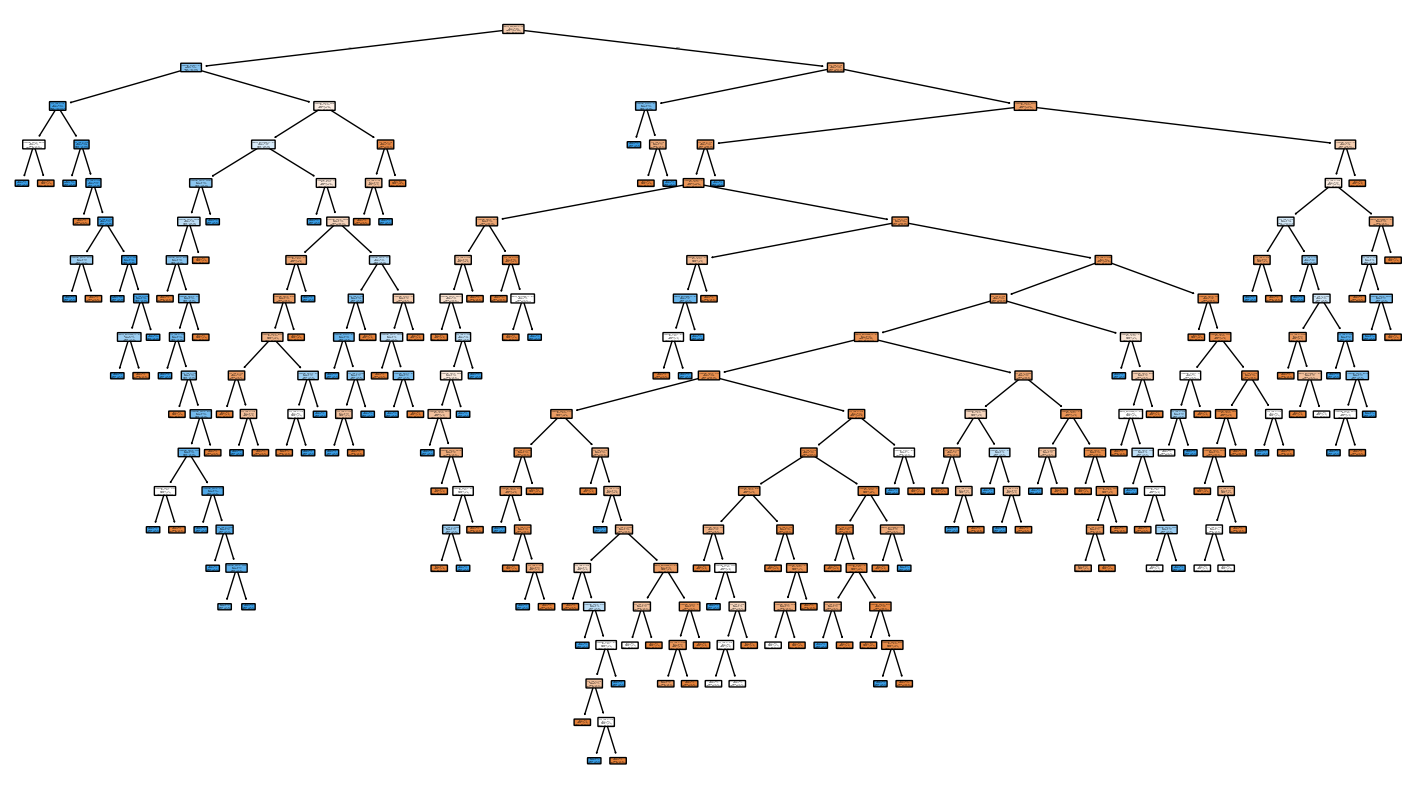

In [43]:
from sklearn.tree import plot_tree


plt.figure(figsize=(18, 10))
plot_tree(
    pipe.named_steps['decisiontreeclassifier'],
    filled=True,
    rounded=True,
    feature_names=pipe.named_steps['columntransformer'].get_feature_names_out(),
    class_names=['Not Survived', 'Survived']
)

plt.show()

In [44]:
from sklearn.metrics import accuracy_score

train_pred = pipe.predict(X_train)
test_pred = pipe.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.9798657718120806
Test Accuracy : 0.7423728813559322


so our trained tree model is overfitting . train dta has 97% per accuracy where as test data only has like 73% only .. 


// ! OVERFITTING 

- Overfitting occurs when a model learns the training data extremely well, even memorizing noise and specific patterns.
- As a result, it achieves very high accuracy on the training data but performs poorly on unseen (testing) data because it fails to generalize.

In Decision Trees, overfitting usually happens when the tree is allowed to grow very deep until most leaf nodes become pure. The tree starts memorizing the training examples instead of learning general decision rules.

---

# Underfitting

- Underfitting occurs when the model is too simple to capture the underlying patterns in the data.
- It performs poorly on both the training data and the testing data because it has not learned enough from the data.

In Decision Trees, underfitting often occurs when the tree depth is too small, preventing the model from exploring important patterns.

---

# Relationship with Tree Depth

Tree depth plays a major role in controlling the complexity of a Decision Tree.

- If `max_depth` is **too small**, the tree cannot learn enough patterns, leading to **underfitting**.max_dpeth=1
- If `max_depth` is **too large**, the tree may memorize the training data, leading to **overfitting**. max_depth=None

However, `max_depth` is **not the only hyperparameter** that affects model complexity. Other important hyperparameters include:

- `min_samples_split`
- `min_samples_leaf`
- `max_leaf_nodes`
- `ccp_alpha` (Cost-Complexity Pruning)

These hyperparameters help control the growth of the tree and improve its ability to generalize to unseen data.

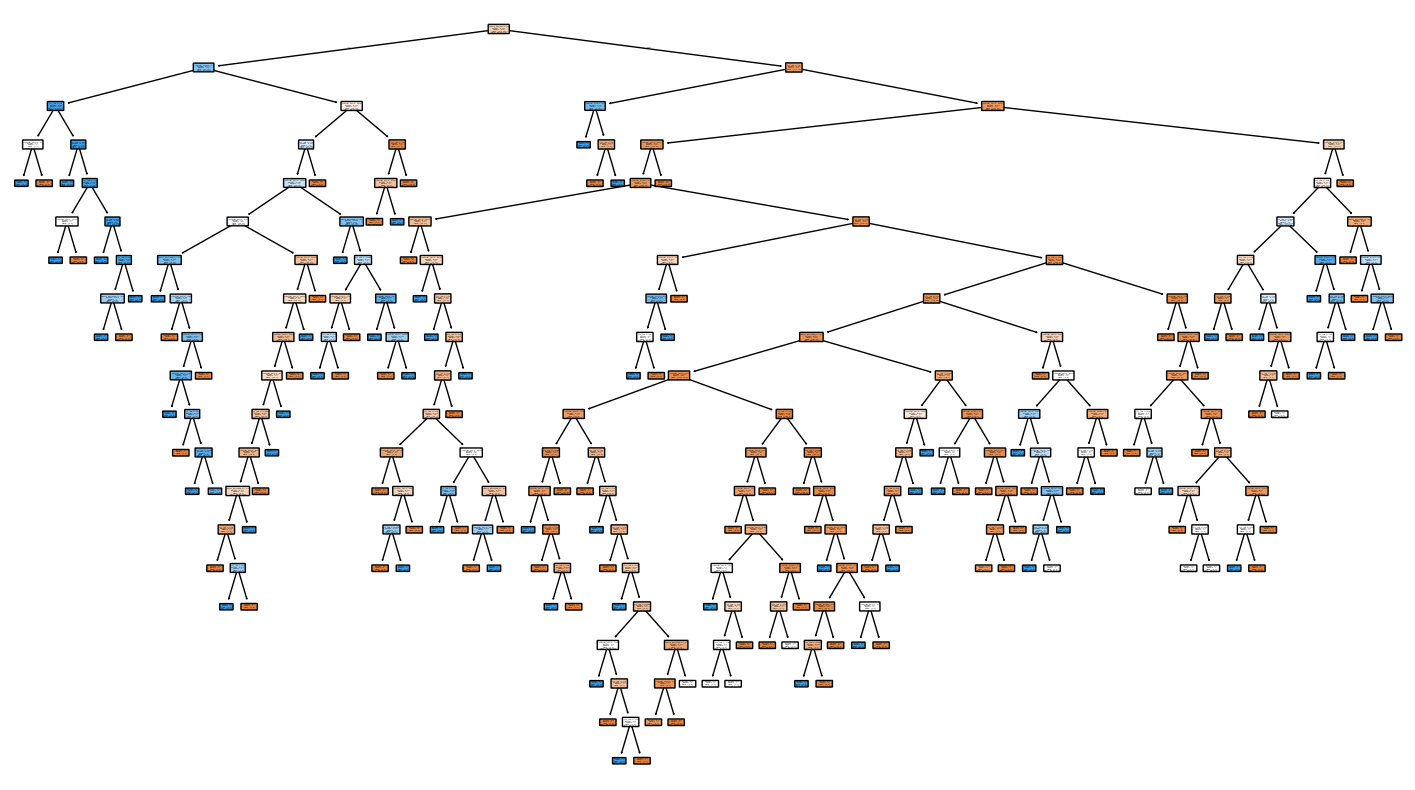

In [45]:

# ovefitting model 


overfit_model=DecisionTreeClassifier(criterion='entropy',max_depth=None)
pipe_overfit=make_pipeline(preprocess,overfit_model)
pipe_overfit.fit(X_train,y_train)


from sklearn.tree import plot_tree


plt.figure(figsize=(18, 10))
plot_tree(
    pipe_overfit.named_steps['decisiontreeclassifier'],
    filled=True,
    rounded=True,
    feature_names=pipe.named_steps['columntransformer'].get_feature_names_out(),
    class_names=['Not Survived', 'Survived']
)

plt.show()

In [46]:



train_pred_overfit = pipe_overfit.predict(X_train)
test_pred_overfit = pipe_overfit.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred_overfit))
print("Test Accuracy :", accuracy_score(y_test, test_pred_overfit))

Train Accuracy: 0.9798657718120806
Test Accuracy : 0.7728813559322034


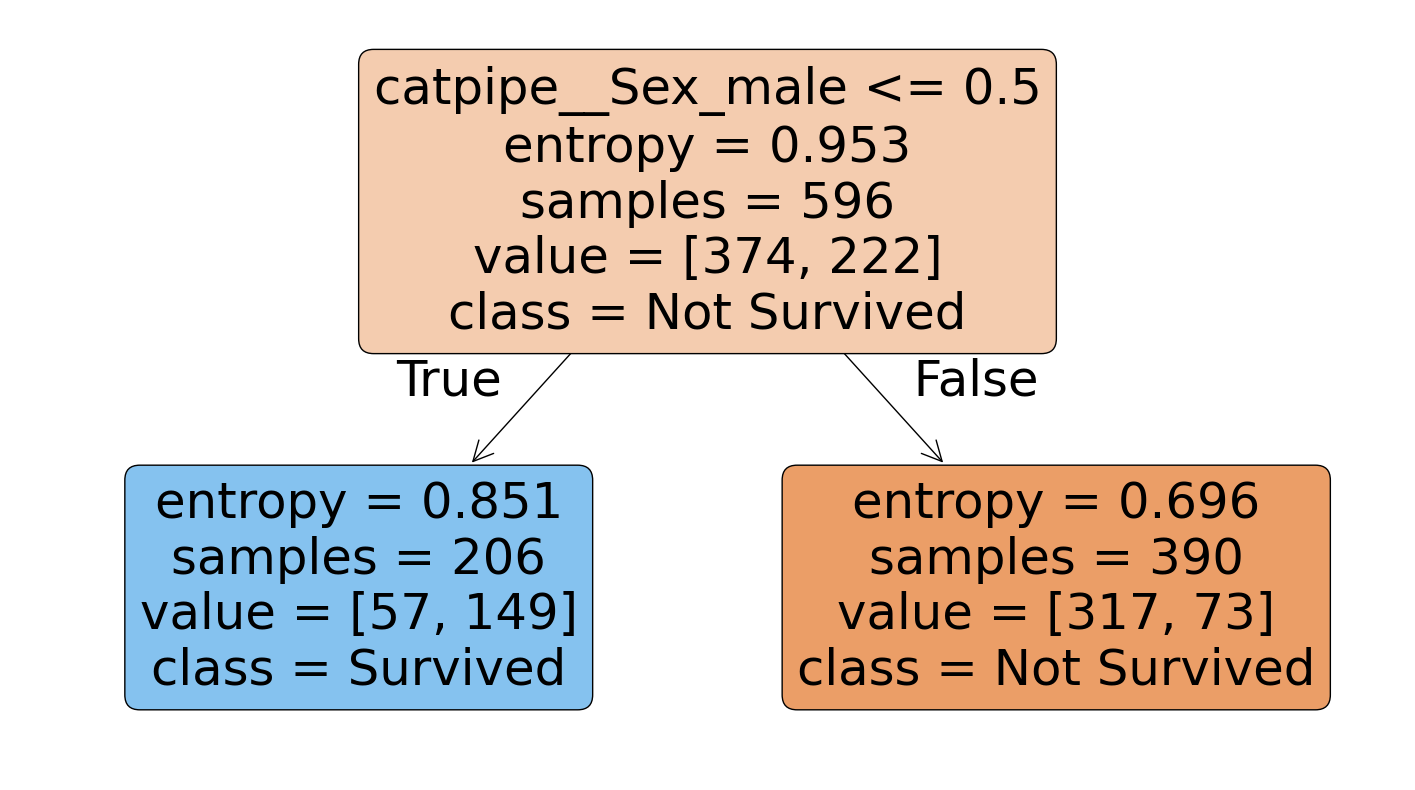

In [47]:
# Underfitting model 

underfit_model=DecisionTreeClassifier(criterion='entropy',max_depth=1)
pipe_underfit=make_pipeline(preprocess,underfit_model)
pipe_underfit.fit(X_train,y_train)


from sklearn.tree import plot_tree


plt.figure(figsize=(18, 10))
plot_tree(
    pipe_underfit.named_steps['decisiontreeclassifier'],
    filled=True,
    rounded=True,
    feature_names=pipe.named_steps['columntransformer'].get_feature_names_out(),
    class_names=['Not Survived', 'Survived']
)

plt.show()

In [48]:
# undefit accuracy 



train_pred_underfit = pipe_underfit.predict(X_train)
test_pred_underfit = pipe_underfit.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred_underfit))
print("Test Accuracy :", accuracy_score(y_test, test_pred_underfit))



'''
Underfitting means:
Low training accuracy
Low testing accuracy
The model is too simple to learn the underlying pattern.

'''

Train Accuracy: 0.7818791946308725
Test Accuracy : 0.7966101694915254


'\nUnderfitting means:\nLow training accuracy\nLow testing accuracy\nThe model is too simple to learn the underlying pattern.\n\n'

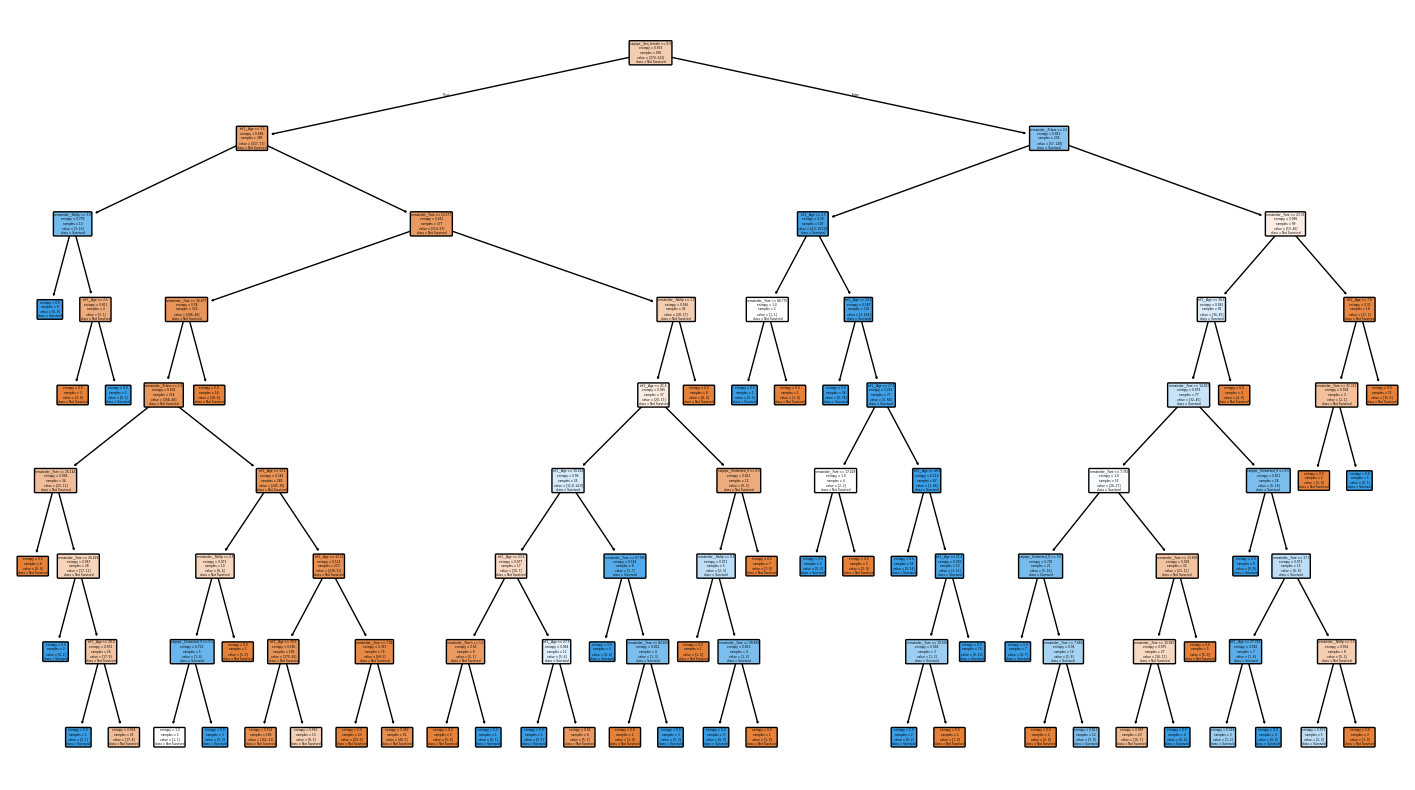

In [49]:
# Good model 

good_model=DecisionTreeClassifier(criterion='entropy',max_depth=8)
pipe_good=make_pipeline(preprocess,good_model)
pipe_good.fit(X_train,y_train)


from sklearn.tree import plot_tree


plt.figure(figsize=(18, 10))
plot_tree(
    pipe_good.named_steps['decisiontreeclassifier'],
    filled=True,
    rounded=True,
    feature_names=pipe.named_steps['columntransformer'].get_feature_names_out(),
    class_names=['Not Survived', 'Survived']
)

plt.show()


In [50]:
train_pred_good = pipe_good.predict(X_train)
test_pred_good = pipe_good.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred_good))
print("Test Accuracy :", accuracy_score(y_test, test_pred_good))

Train Accuracy: 0.9093959731543624
Test Accuracy : 0.8067796610169492


Decision tree has many hyperparameters not all are needed we will learn some imp ones onyly and train them uisng GridSearchCV . some of them are like max_depth , 
- min_samples_split=100 (say) then it will split only if thera are 100 or more rows in the node else not 
- max_feature 
- criterion
- ccp_alpha - ccp_alpha controls cost-complexity pruning in a Decision Tree.
It helps prevent overfitting by removing splits/branches that do not improve the tree enough. 
Small ccp_alpha → larger, more complex tree
Large ccp_alpha → smaller, simpler tree




// ! -----------------GridSearchCv-------------------------
# GridSearchCv # GridSearchCV

#### GridSearchCV is a scikit-learn tool that automatically finds
#### the best combination of hyperparameters for a machine-learning model.

- It tries all parameter combinations you provide and evaluates
- them using cross-validation.

param_grid = {
    "max_depth": [2, 3, 4, 5],
    "max_features": [None, "sqrt", "log2"],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    estimator=model,          # e.g., Decision Tree, SVM, KNN
    param_grid=param_grid,
    scoring="accuracy",
    cv=5
)

scoring="accuracy" → choose the model with best average accuracy
scoring="f1"       → useful for imbalanced classification
scoring="precision"→ useful when false positives are costly
scoring="recall"   → useful when false negatives are costly

// ! ---------------------Cross-Validation-------------------

# Cross-Validation 

it is the way to check how well a model peform with unseen data.  Usally what we do is we train-test-split data and see the result in unseeen test data and calc accuracy but it might not be the reliable to way to determine that the model is the best one... 


- so we use Cross-validation, what we do here is say CV=5 then there is somethign called 
- k-fold-cross-validation 

cv=5 so we divide the trainign data into 5 equal part --->> part1| part2| part3 | part4 | part 5




// !         so in round 1 , part 2,3,4,5, are training data and we validate ( test ) in part 1 

// !         so in round 2 , part 1,3,4,5, are training data and we validate ( test ) in part 2

// !         so in round 1 , part 1,2,4,5, are training data and we validate ( test ) in part 3

// !         so in round 1 , part 2,3,1,5, are training data and we validate ( test ) in part 4

// !         so in round 1 , part 1,2,3,4,, are training data and we validate ( test ) in part 5


so this doing this we get accuracy for each round and at least we take the mean accuracy and see the real accuracy cuz in one split may be you get lucky , test data might be really good or bad . 


# syntx

validaton = crossvalidatin( estimator=model, 
                        cv=4, 
                        x= xtrain,
                        y=ytrain,
                        scoring='arrucy' )

In [ ]:
# now lests do Gridsearchcv first 


# above model=dt was used with criterion='gini' and accuracy was 0.7322033898305085, now lest tune it 



from sklearn.model_selection import GridSearchCV

hyperparameters={
    "max_depth":[1,2,3,4,5,6,7,8,9,10],
    "criterion":["gini","entropy"],
    "min_samples_split":[2,5,10],
    "ccp_alpha":[0.0,0.1,0.5],
    "splitter":["best","random"]

}

grid=GridSearchCV(
    estimator=pipe,
    param_grid=hyperparameters,
    cv=5,
    scoring='accuracy',

)

grid.fit(X_train,y_train)

""".  The error is because you passed model to GridSearchCV:
estimator=model
But model is only the bare Decision Tree. Your raw X_train still has strings such as "male" and "female", and a bare Decision Tree cannot convert them to numbers.
Your working model is actually the full pipeline:
pipe = make_pipeline(preprocess, model)
That pipeline does:
impute missing values → one-hot encode Sex/Embarked → train Decision Tree
So give pipe to GridSearchCV, not model. Because the tree is inside a pipeline, prefix every Decision Tree parameter with:
decisiontreeclassifier__


"""

ValueError: Invalid parameter 'ccp_alpha' for estimator Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf1', SimpleImputer(),
                                                  ['Age']),
                                                 ('catpipe',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Embarked', 'Sex'])])),
                ('decisiontreeclassifier', DecisionTreeClassifier())]). Valid parameters are: ['memory', 'steps', 'transform_input', 'verbose'].

In [53]:
from sklearn.model_selection import GridSearchCV

hyperparameters = {
    "decisiontreeclassifier__max_depth": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "decisiontreeclassifier__criterion": ["gini", "entropy"],
    "decisiontreeclassifier__min_samples_split": [2, 5, 10],
    "decisiontreeclassifier__ccp_alpha": [0.0, 0.001, 0.01],
    "decisiontreeclassifier__splitter": ["best", "random"]
}

grid = GridSearchCV(
    estimator=pipe,               # use pipeline, not model
    param_grid=hyperparameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'decisiontreeclassifier__ccp_alpha': [0.0, 0.001, ...], 'decisiontreeclassifier__criterion': ['gini', 'entropy'], 'decisiontreeclassifier__max_depth': [1, 2, ...], 'decisiontreeclassifier__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: in

In [55]:
print(grid.best_estimator_)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf1', SimpleImputer(),
                                                  ['Age']),
                                                 ('catpipe',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Embarked', 'Sex'])])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(ccp_alpha=0.001, criterion='entropy',
                                   

In [56]:
print(grid.best_params_)

{'decisiontreeclassifier__ccp_alpha': 0.001, 'decisiontreeclassifier__criterion': 'entropy', 'decisiontreeclassifier__max_depth': 4, 'decisiontreeclassifier__min_samples_split': 2, 'decisiontreeclassifier__splitter': 'random'}


these above are the best tuned hyper parameters 

In [57]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))

Test accuracy: 0.8169491525423729


accuracy jumped from 73% to 81% ..

In [61]:
# now lets corss validate the model 

from sklearn.model_selection import cross_val_score

cross=cross_val_score(
    estimator=pipe,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='accuracy'
)
cross

array([0.74166667, 0.73109244, 0.76470588, 0.76470588, 0.75630252])

In [62]:
cross.mean()

np.float64(0.7516946778711484)

But since we already have GridSearchCV, no need to cross-validate pipe separately unless we. are comparing the base model with the tuned model. For the tuned model, GridSearchCV already performs cross-validation internally